# Week 2 – Classification
## Logistic Regression: From Intuition to Gradient Descent

Learning goals:

1. Motivate **classification** and compare it with linear regression.
2. Introduce the **logistic regression model**:
   $$
   f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w} \cdot \vec{x} + b)
   $$
3. Understand **decision boundaries**:
   - Linear boundaries in the original feature space.
   - Nonlinear boundaries via **feature transformations** (polynomial features).
4. Define the **logistic loss** and the **cost function**.
5. Derive and implement the **gradients** of the cost function.
6. Implement **gradient descent** and visualize **cost vs iterations**.

Notation (we keep it explicit and consistent):

- Vectors: $\vec{w}, \vec{x}$ (conceptual). In code they are NumPy arrays.
- Hypothesis (model): $f_{\vec{w}, b}(\vec{x})$.
- For sample $i$: $f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = f_{\vec{w}, b}(\vec{x}^{(i)})$.


In [1]:
%pip install numpy matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

## 1. Motivation: Regression vs Classification

In **linear regression**, the goal is to predict a **real-valued output**:
$$
\hat{y} \in \mathbb{R}
$$

Examples:
- Predicting house prices.
- Predicting temperature.

In **binary classification**, the goal is to predict a **class label**:
$$
\hat{y} \in \{0, 1\}
$$

Examples:
- Email: spam ($y = 1$) vs not spam ($y = 0$).
- Transaction: fraudulent ($y = 1$) vs normal ($y = 0$).
- Tumor: malignant ($y = 1$) vs benign ($y = 0$).

Linear regression is not a natural probability model. Its output is a linear score:
$$
\vec{w}\cdot\vec{x} + b \in \mathbb{R}
$$

This value can be negative, larger than 1, or any real number. That makes it hard to interpret as a probability.
For classification, a more useful output is a number between 0 and 1.

The model output is interpreted as an **estimated probability** that the class is 1:
$$
f_{\vec{w}, b}(\vec{x}) \approx P(y = 1 \mid \vec{x}; \vec{w}, b)
$$

The value $f_{\vec{w}, b}(\vec{x})$ is the model's estimate of the probability. It is not a guarantee about the real world; it is the probability according to the model and its learned parameters.

A class prediction can be obtained from the estimated probability:
- Predict $\hat{y} = 1$ if $f_{\vec{w}, b}(\vec{x}) \ge 0.5$.
- Predict $\hat{y} = 0$ otherwise.

The threshold $0.5$ is a natural default, but it is not mandatory. In real applications, the threshold may change depending on the cost of false positives and false negatives. For example, fraud detection and medical diagnosis often care about these tradeoffs differently.


## 2. Logistic Regression Model

The **hypothesis** (model) is:
$$
f_{\vec{w}, b}(\vec{x}) = \sigma(z)
$$
where
$$
z = \vec{w} \cdot \vec{x} + b
$$

The quantity $z$ is a linear score. It can be any real number. The role of the sigmoid function is to convert this score into a number between 0 and 1.

The function $\sigma(z)$ is the **sigmoid**:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Interpretation:
$$
f_{\vec{w}, b}(\vec{x}) \approx P(y = 1 \mid \vec{x}; \vec{w}, b)
$$

For sample $i$:
$$
f_{\vec{w}, b}(\vec{x}^{(i)}) = \sigma(\vec{w} \cdot \vec{x}^{(i)} + b)
$$

### Log-odds interpretation

Let
$$
p = P(y = 1 \mid \vec{x}; \vec{w}, b).
$$

The **odds** compare the probability of class 1 with the probability of class 0:
$$
\text{odds} = \frac{p}{1-p}.
$$

Examples:

- If $p = 0.5$, then $\text{odds} = \frac{0.5}{0.5} = 1$. Class 1 and class 0 are equally likely.
- If $p = 0.8$, then $\text{odds} = \frac{0.8}{0.2} = 4$. Class 1 is four times as likely as class 0.
- If $p = 0.2$, then $\text{odds} = \frac{0.2}{0.8} = 0.25$. Class 1 is less likely than class 0.

The **log-odds** are the logarithm of the odds:
$$
\log\left(\frac{p}{1-p}\right).
$$

The log-odds are useful because they can take any real value:

- $p = 0.5$ gives log-odds $0$.
- $p > 0.5$ gives positive log-odds.
- $p < 0.5$ gives negative log-odds.

Logistic regression assumes that these log-odds are a linear function of the features:
$$
\log\left(\frac{p}{1-p}\right) = \vec{w}\cdot\vec{x} + b.
$$

This is another way to understand the model: logistic regression is linear on the log-odds scale, and the sigmoid converts that linear score back into a probability-like value between 0 and 1.


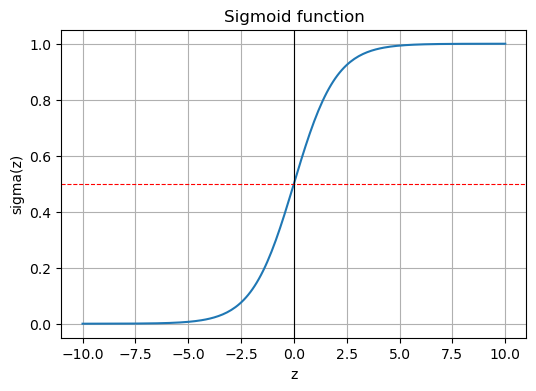

In [3]:
def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))


# Visualize the sigmoid function
z_values = np.linspace(-10, 10, 200)
sig_values = sigmoid(z_values)

plt.figure()
plt.plot(z_values, sig_values)
plt.title("Sigmoid function")
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.ylim(-0.05, 1.05)
plt.axhline(0.5, color="red", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

The plot shows $\sigma(z)$:

- For large negative $z$, $\sigma(z) \approx 0$.
- For large positive $z$, $\sigma(z) \approx 1$.
- At $z = 0$, $\sigma(0) = 0.5$.

This shape is useful for modeling **probabilities**:

- If $z$ is very negative, $f_{\vec{w}, b}(\vec{x})$ is close to 0 (the model is confident that $y = 0$).
- If $z$ is very positive, $f_{\vec{w}, b}(\vec{x})$ is close to 1 (the model is confident that $y = 1$).
- Around $z = 0$, $f_{\vec{w}, b}(\vec{x}) \approx 0.5$ (the model is uncertain).

The model has three conceptual steps:

1. $z = \vec{w}\cdot\vec{x}+b$ gives a linear score.
2. $\sigma(z)$ turns that score into a probability-like output.
3. A threshold turns the probability-like output into a class prediction.


## 3. Decision Boundary - Linear Case

The hypothesis is:
$$
f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w} \cdot \vec{x} + b).
$$

With the default threshold, the prediction rule is:
$$
\hat{y} =
\begin{cases}
1 & \text{if } f_{\vec{w}, b}(\vec{x}) \ge 0.5 \\
0 & \text{otherwise.}
\end{cases}
$$

Because $\sigma(z) \ge 0.5$ if and only if $z \ge 0$, then:
$$
f_{\vec{w}, b}(\vec{x}) \ge 0.5
\iff
\vec{w} \cdot \vec{x} + b \ge 0.
$$

The **decision boundary** is defined by the points where the model is exactly at probability 0.5:
$$
\vec{w} \cdot \vec{x} + b = 0.
$$

That equation is the boundary between the region predicted as class 0 and the region predicted as class 1.

- In 2D ($x_1, x_2$), this is a **line**.
- In 3D, it is a **plane**.
- In general, it is a **hyperplane**.

The sigmoid changes the scale of the output, but the boundary at threshold 0.5 comes from the linear score $\vec{w}\cdot\vec{x}+b$.


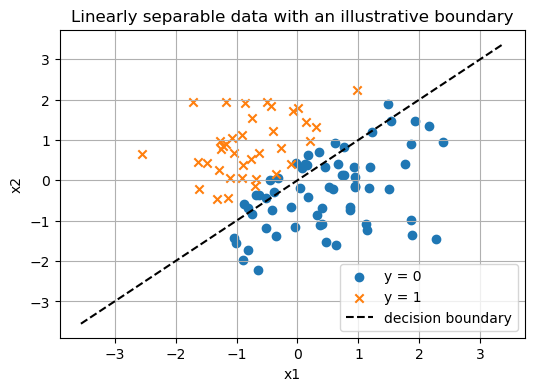

In [4]:
# Generate a simple linearly separable 2D dataset
np.random.seed(0)

m = 100  # number of examples
X_linear = np.random.randn(m, 2)

# Underlying "true" boundary: x2 = x1 + 0.5
# Label 1 if above the line, 0 if below
y_linear = (X_linear[:, 1] > X_linear[:, 0] + 0.5).astype(int)


def plot_linear_data_with_boundary(w, b, X, y, title):
    """Plot 2D data (X, y) and a linear decision boundary defined by w, b."""
    plt.figure()
    plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", label="y = 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="x", label="y = 1")

    # Decision boundary: w0*x1 + w1*x2 + b = 0  => x2 = -(w0*x1 + b) / w1
    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    if abs(w[1]) > 1e-6:
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        plt.plot(x1_vals, x2_vals, "k--", label="decision boundary")
    else:
        x1_line = -b / w[0]
        plt.axvline(x1_line, color="k", linestyle="--", label="decision boundary")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


# Example boundary (not trained yet). This is only to visualize what a boundary looks like.
w_example = np.array([1.0, -1.0])
b_example = 0.0

plot_linear_data_with_boundary(w_example, b_example, X_linear, y_linear,
                               "Linearly separable data with an illustrative boundary")

## 3.1 Nonlinear Boundaries via Feature Transformations

With the **original features** $x_1, x_2$, a logistic regression model
$$
f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w} \cdot \vec{x} + b)
$$
can only represent **linear** decision boundaries in the $(x_1, x_2)$ plane.

This does not mean logistic regression is useless for nonlinear-looking data. It means that the boundary is linear in whatever feature space is given to the model.

If the input is transformed using a **feature mapping**:
$$
\vec{\phi}(\vec{x}) =
[x_1,\, x_2,\, x_1^2,\, x_2^2,\, x_1 x_2],
$$
and the hypothesis is defined in the new feature space as
$$
f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w} \cdot \vec{\phi}(\vec{x}) + b),
$$
then the decision boundary is
$$
\vec{w} \cdot \vec{\phi}(\vec{x}) + b = 0.
$$

This equation is still linear in the transformed features $\vec{\phi}(\vec{x})$, but it can appear **nonlinear in the original $(x_1, x_2)$ space**.

For example, a boundary involving $x_1^2 + x_2^2$ can produce a circle. The nonlinear shape comes from the feature transformation, not from the sigmoid alone.

The circular dataset below illustrates a case where the boundary is nonlinear in the original feature space.


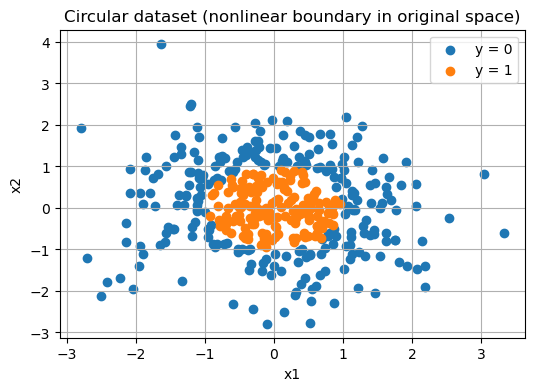

In [5]:
# Generate a circular dataset
np.random.seed(1)

m_circ = 400
X_circ = np.random.randn(m_circ, 2)
r = np.sqrt(X_circ[:, 0] ** 2 + X_circ[:, 1] ** 2)

# Label 1 if inside circle of radius ~1, else 0
y_circ = (r < 1.0).astype(int)

plt.figure()
plt.scatter(X_circ[y_circ == 0, 0], X_circ[y_circ == 0, 1], label="y = 0")
plt.scatter(X_circ[y_circ == 1, 0], X_circ[y_circ == 1, 1], label="y = 1")
plt.title("Circular dataset (nonlinear boundary in original space)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()


def polynomial_features(X):
    """Simple polynomial feature mapping for 2D inputs.
    
    phi(x1, x2) = [x1, x2, x1^2, x2^2, x1*x2]
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    X_poly = np.column_stack([
        x1,
        x2,
        x1**2,
        x2**2,
        x1 * x2
    ])
    return X_poly

## 4. Cost Function for Logistic Regression

The parameters $\vec{w}, b$ should make the model's predictions
$$
f_{\vec{w}, b}(\vec{x}^{(i)})
$$
close to the true labels $y^{(i)}$.

For classification, "close" does not mean the same thing as in linear regression. If squared error is used with the sigmoid output, the optimization problem becomes less convenient and can behave poorly. Logistic regression uses a loss function designed for probabilities and binary labels.

For **logistic regression**, the **logistic loss** per example is:
$$
\ell^{(i)} =
\begin{cases}
-\log\left(f_{\vec{w}, b}(\vec{x}^{(i)})\right) & \text{if } y^{(i)} = 1, \\
-\log\left(1 - f_{\vec{w}, b}(\vec{x}^{(i)})\right) & \text{if } y^{(i)} = 0.
\end{cases}
$$

Intuition:

- If $y^{(i)} = 1$, the desired value of $f_{\vec{w}, b}(\vec{x}^{(i)})$ is close to 1. Then $-\log(\cdot)$ is small.
- If $y^{(i)} = 0$, the desired value of $f_{\vec{w}, b}(\vec{x}^{(i)})$ is close to 0. Then $-\log(1 - \cdot)$ is small.
- **Confident wrong predictions** produce a very large loss.

If the true class is 1 but the model predicts a probability close to 0, the loss becomes very large. The model is punished strongly for being confidently wrong.

Both cases can be combined into one expression:
$$
\ell^{(i)} =
-\left[
y^{(i)} \log f_{\vec{w}, b}(\vec{x}^{(i)})
+
(1 - y^{(i)}) \log\left(1 - f_{\vec{w}, b}(\vec{x}^{(i)})\right)
\right].
$$

This expression selects the correct term automatically:

- If $y^{(i)}=1$, then $(1-y^{(i)})=0$, so only the first term remains.
- If $y^{(i)}=0$, then $y^{(i)}=0$, so only the second term remains.

The overall cost function is the average loss over all $m$ examples:
$$
J(\vec{w}, b) =
-\frac{1}{m}
\sum_{i=1}^m
\left[
y^{(i)} \log f_{\vec{w}, b}(\vec{x}^{(i)})
+
(1 - y^{(i)}) \log\big(1 - f_{\vec{w}, b}(\vec{x}^{(i)})\big)
\right].
$$

For logistic regression, this cost is also known as **binary cross-entropy** or **negative log-likelihood**.


In [6]:
def compute_cost(w, b, X, y):
    """Compute logistic regression cost J(w, b) using explicit model."""
    m, n = X.shape

    # For each example i: f_{w,b}^{(i)}(x^{(i)}) = sigmoid(w^T x^{(i)} + b)
    z = X @ w + b
    f = sigmoid(z)

    # Mathematically we use log(f) and log(1-f). In code, clip to avoid log(0).
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    return J


# Quick test on linear dataset with zero parameters
w_test = np.zeros(2)
b_test = 0.0
J_test = compute_cost(w_test, b_test, X_linear, y_linear)
J_test

0.6931471805599453

## 5. Gradients of the Cost Function

The goal is to minimize $J(\vec{w}, b)$ with respect to $\vec{w}$ and $b$.  
**Gradient descent** requires the partial derivatives of the cost function.

A useful result of logistic regression is that the gradients have a familiar structure:

$$
\text{error}^{(i)} = f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}.
$$

That is:

$$
\text{error} = \text{model prediction} - \text{true label}.
$$

For each parameter $w_j$:
$$
\frac{\partial J}{\partial w_j}
=
\frac{1}{m}
\sum_{i=1}^m
\left(
f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}
\right)
x^{(i)}_j,
$$
and for the bias:
$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^m
\left(
f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}
\right).
$$

The gradient for $w_j$ multiplies the error by feature $x_j$. If a feature contributes to a wrong prediction, its weight is adjusted in the direction that reduces that error.

Vectorized view (conceptual):

1. Compute all $z^{(i)} = \vec{w} \cdot \vec{x}^{(i)} + b$ and
   $$
   f_{\vec{w}, b}(\vec{x}^{(i)}) = \sigma(z^{(i)}).
   $$
2. Define the error vector $\vec{e}$ with components
   $$
   e^{(i)} = f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}.
   $$
3. Then
   $$
   \nabla_{\vec{w}} J = \frac{1}{m} X^\top \vec{e}, \quad
   \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m e^{(i)}.
   $$

In code, this becomes: compute predictions, compute errors, then average their contributions to each parameter.


In [7]:
def compute_gradient(w, b, X, y):
    """Compute gradients dJ/dw and dJ/db with explicit model."""
    m, n = X.shape

    # f_{w,b}^{(i)}(x^{(i)})
    z = X @ w + b
    f = sigmoid(z)

    error = f - y  # e^{(i)} = f_{w,b}^{(i)}(x^{(i)}) - y^{(i)}

    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db


# Quick test
dj_dw_test, dj_db_test = compute_gradient(w_test, b_test, X_linear, y_linear)
dj_dw_test, dj_db_test

(array([ 0.29574313, -0.24721321]), 0.13)

## 6. Gradient Descent

To minimize $J(\vec{w}, b)$, the parameters are updated in the opposite direction
of the gradient.

For each weight $w_j$:
$$
w_j := w_j - \alpha \frac{\partial J}{\partial w_j},
$$
and for the bias:
$$
b := b - \alpha \frac{\partial J}{\partial b},
$$

where $\alpha > 0$ is the **learning rate**.

The learning rate controls the size of each step:

- If $\alpha$ is too small, training can be very slow.
- If $\alpha$ is too large, the cost may fail to decrease or may even diverge.
- A good $\alpha$ should make the cost decrease steadily.

Algorithm (high level):

1. Initialize $\vec{w}$ and $b$ (e.g., zeros).
2. Repeat for a number of iterations:
   - Compute predictions $f_{\vec{w},b}(\vec{x}^{(i)})$.
   - Compute the errors $f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}$.
   - Compute $\frac{\partial J}{\partial w_j}$ and $\frac{\partial J}{\partial b}$.
   - Update $\vec{w}$ and $b$ with the rules above.
3. Track $J(\vec{w}, b)$ to see if it decreases.

The following code trains the model on the linear dataset and visualizes:

1. The cost decreasing over iterations.
2. The learned decision boundary in the original feature space.


In [8]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    """Run gradient descent to optimize w and b."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost(w, b, X, y)
        J_history.append(J)

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: J(w, b) = {J:.4f}")

    return w, b, J_history


# Train on the linear dataset
m_lin, n_lin = X_linear.shape
w0 = np.zeros(n_lin)
b0 = 0.0

alpha = 0.5
num_iters = 200

w_trained, b_trained, J_hist = gradient_descent(
    X_linear, y_linear, w0, b0, alpha, num_iters, print_every=50
)

w_trained, b_trained

Iteration    0: J(w, b) = 0.6156
Iteration   50: J(w, b) = 0.1860
Iteration  100: J(w, b) = 0.1456
Iteration  150: J(w, b) = 0.1271
Iteration  199: J(w, b) = 0.1159


(array([-3.63395384,  3.18255063]), -2.0206447791397713)

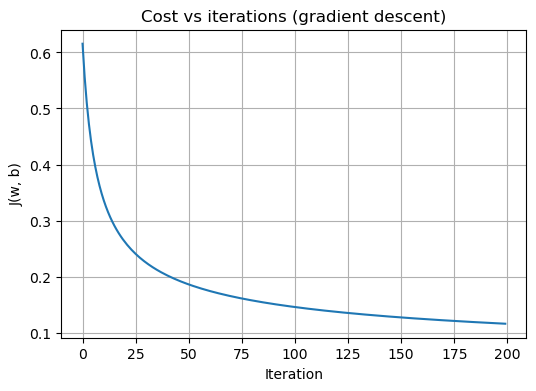

In [9]:
plt.figure()
plt.plot(J_hist)
plt.title("Cost vs iterations (gradient descent)")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.show()

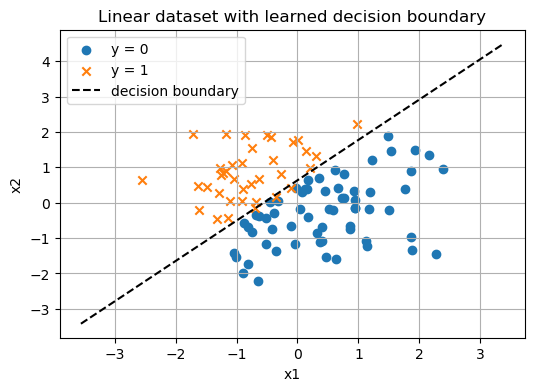

In [10]:
plot_linear_data_with_boundary(
    w_trained, b_trained, X_linear, y_linear,
    "Linear dataset with learned decision boundary"
)

## 7. Summary (Hour 1)

In this first hour we have built the full path from classification intuition to a trainable logistic regression model.

1. **Motivation**  
   - Regression predicts real values, while classification predicts categories.
   - Linear regression is not ideal as a probability model because its output can be any real number.
   - Logistic regression outputs an estimated probability:
     $$
     f_{\vec{w}, b}(\vec{x}) \approx P(y = 1 \mid \vec{x}; \vec{w}, b).
     $$
   - The default threshold is $0.5$, but different applications may use different thresholds.

2. **Logistic regression model**  
   - Linear score:
     $$
     z = \vec{w}\cdot\vec{x}+b.
     $$
   - Hypothesis:
     $$
     f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w} \cdot \vec{x} + b).
     $$
   - Sigmoid $\sigma(z)$ maps any real number to the interval $(0, 1)$.
   - Logistic regression is linear on the log-odds scale: the score $z = \vec{w}\cdot\vec{x}+b$ represents $\log\left(\frac{p}{1-p}\right)$.

3. **Decision boundary**  
   - With threshold $0.5$:

     $$
     f_{\vec{w},b}(\vec{x}) \ge 0.5 \iff \vec{w} \cdot \vec{x} + b \ge 0.
     $$
   - The decision boundary is given by
     $$
     \vec{w} \cdot \vec{x} + b = 0,
     $$
     which is linear in the original features.
   - With feature maps $\vec{\phi}(\vec{x})$, logistic regression can represent nonlinear-looking boundaries in the original input space.
   - The nonlinear shape comes from the transformed features, not from the sigmoid alone.

4. **Cost function**  
   - Per-example logistic loss:
     $$
     \ell^{(i)} =
     -\left[
     y^{(i)} \log f_{\vec{w}, b}(\vec{x}^{(i)})+
     (1 - y^{(i)}) \log\left(1 - f_{\vec{w}, b}(\vec{x}^{(i)})\right)
     \right].
     $$
   - Overall cost:
     $$
     J(\vec{w}, b) =
     -\frac{1}{m}
     \sum_{i=1}^m
     \left[
     y^{(i)} \log f_{\vec{w}, b}(\vec{x}^{(i)})+
     (1 - y^{(i)}) \log\left(1 - f_{\vec{w}, b}(\vec{x}^{(i)})\right)
     \right].
     $$
   - This loss strongly penalizes confident wrong predictions.

5. **Gradients and gradient descent**  
   - The key error term is:
     $$
     f_{ \vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}.
     $$
   - Gradients:
     $$
     \frac{\partial J}{\partial w_j} =
     \frac{1}{m}
     \sum_{i=1}^m
     \left(
     f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}
     \right) x_j^{(i)},
     $$


     $$
     \frac{\partial J}{\partial b}=
     \frac{1}{m}
     \sum_{i=1}^m
     \left(
     f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)}
     \right).
     $$
   - Gradient descent updates:
     $$
     w_j := w_j - \alpha \frac{\partial J}{\partial w_j}, \quad
     b := b - \alpha \frac{\partial J}{\partial b}.
     $$
   - We implemented gradient descent, observed the **cost decreasing**, and visualized the **learned decision boundary** on a 2D dataset.

